# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [3]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [4]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [5]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=11
var.compute_is_stationary(phi)

True

In [6]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

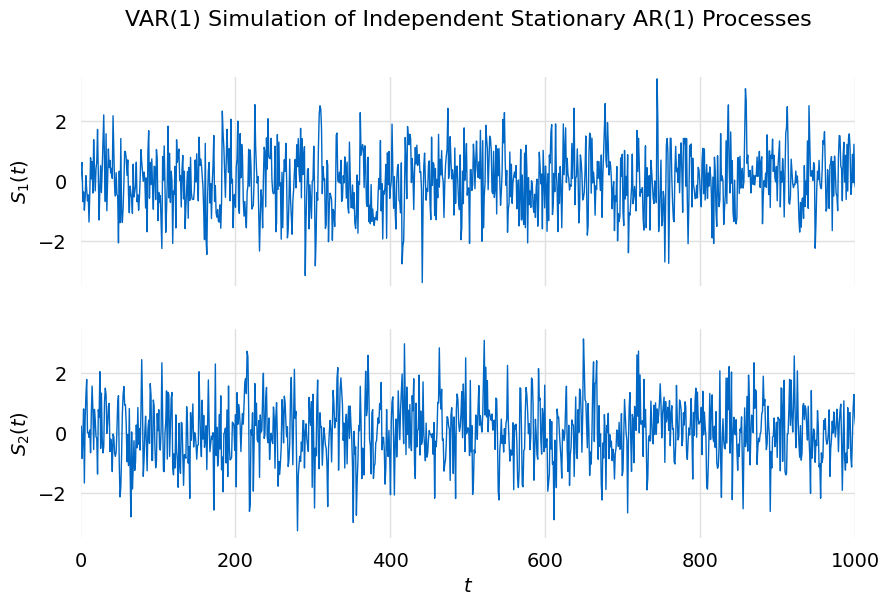

In [7]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

### Coupled $\text{AR}(1)$

In [8]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)

True

In [9]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

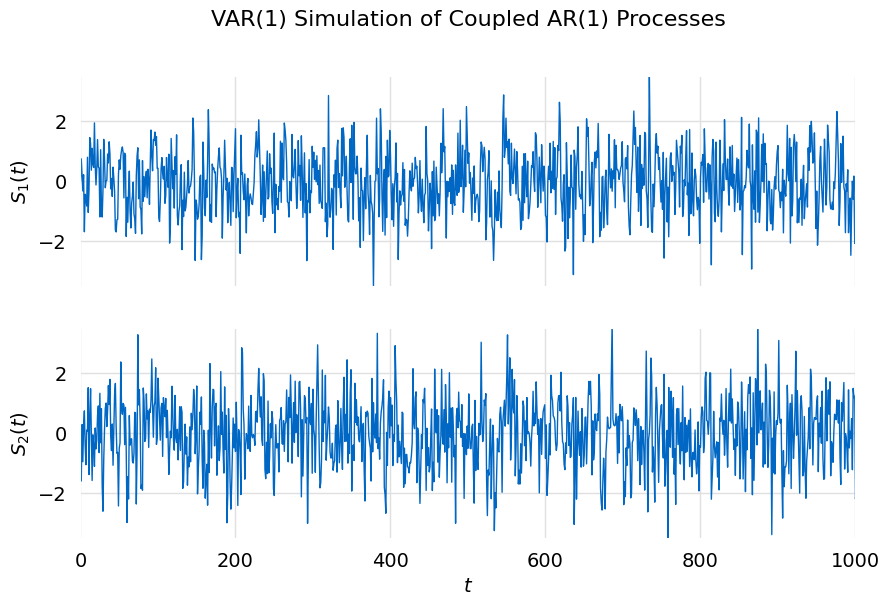

In [10]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [23]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)

True

In [24]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

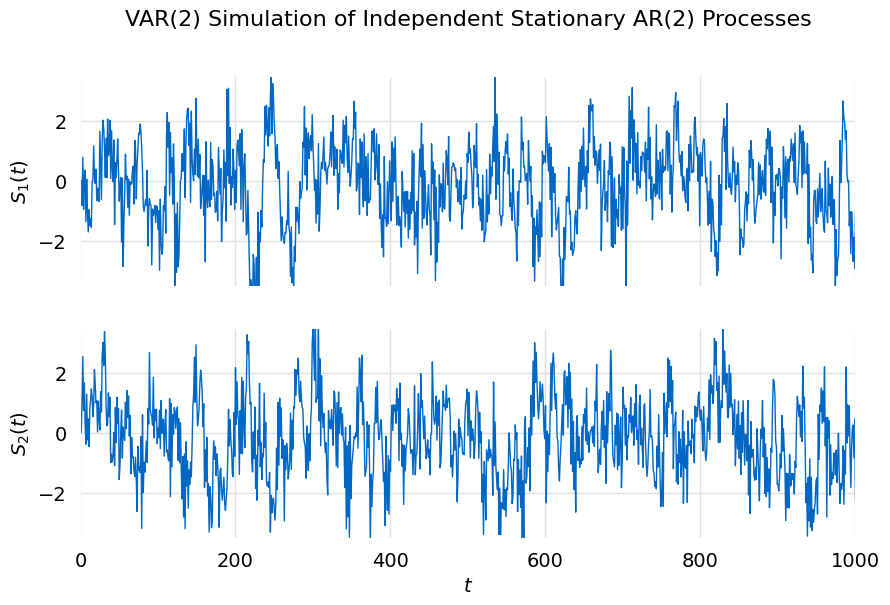

In [25]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

### Coupled $\text{AR}(2)$

In [14]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)

True

In [15]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

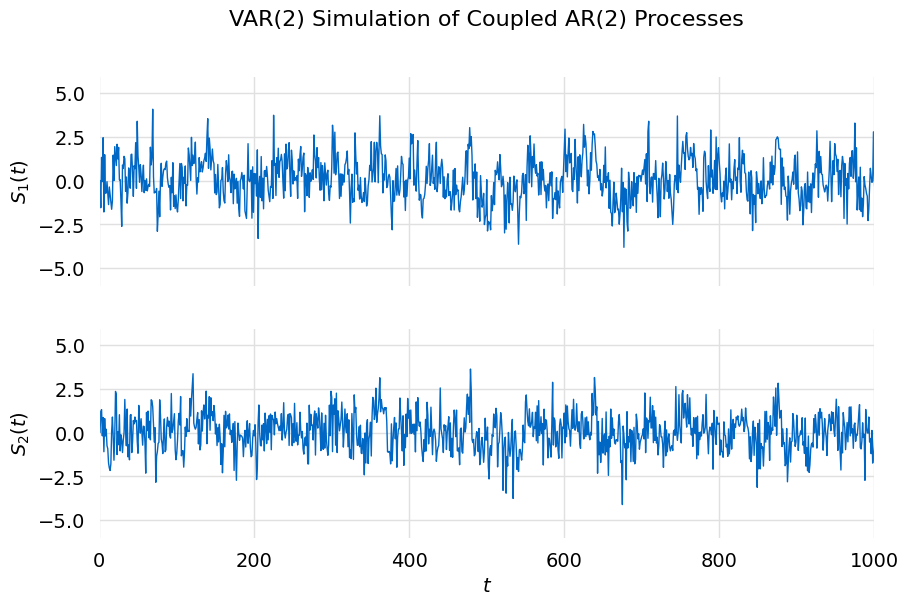

In [16]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [17]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=11

In [18]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

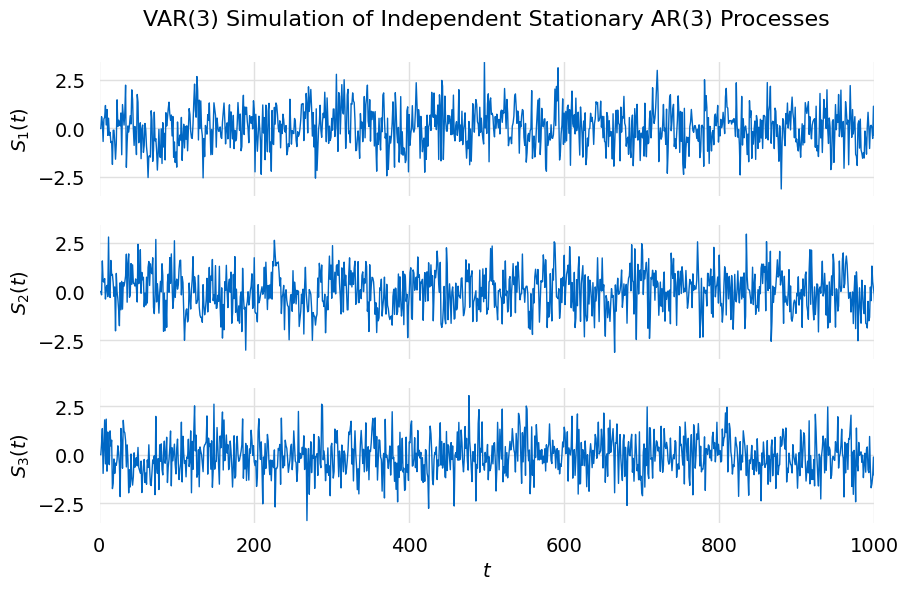

In [19]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

### Coupled $\text{AR}(3)$

In [20]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)


True

In [21]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

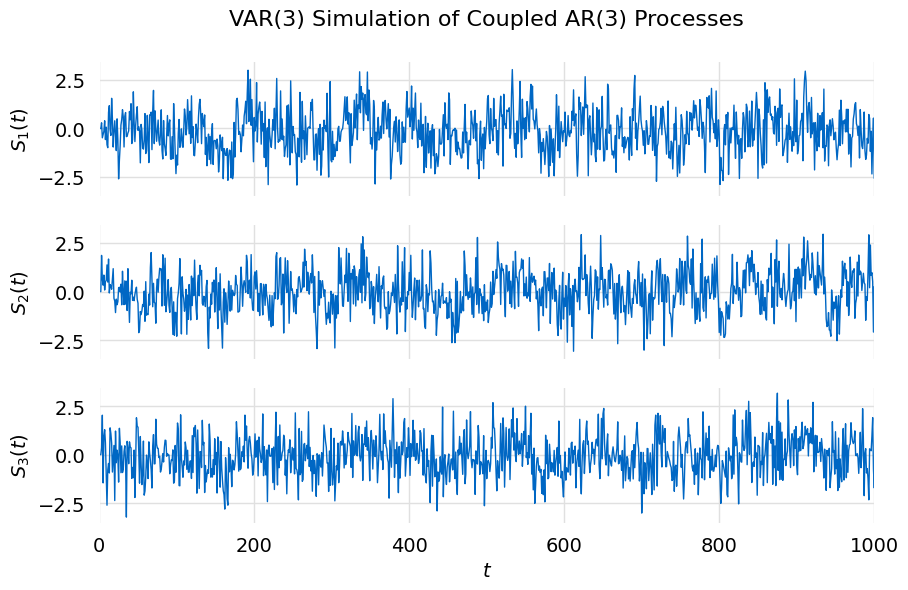

In [22]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))